# SHD LSM Topology Diagnostics

This notebook aggregates topology diagnostic outputs from `runs/diagnostics/topology_summary.csv` and prepares tables/figures for manual mechanism analysis.

Intended causal chain to inspect, without making final claims here:

`same density -> different graph topology -> different recurrent dynamics -> different representation/readout separability -> different test accuracy`

## Imports and settings

In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()
if not (ROOT / "runs").exists() and (ROOT.parent / "runs").exists():
    ROOT = ROOT.parent

CSV_PATH = ROOT / "runs" / "diagnostics" / "topology_summary.csv"
OUT_DIR = ROOT / "runs" / "diagnostics"
FIG_DIR = OUT_DIR / "figures"
GROUP_SUMMARY_PATH = OUT_DIR / "topology_group_summary.csv"
SEED_SUMMARY_PATH = OUT_DIR / "topology_seed_summary.csv"
PAPER_TABLE_PATH = OUT_DIR / "topology_paper_table.csv"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

METHOD_ORDER = ["no_recurrence", "random_sparse", "grad_r", "learned_lowrank"]
METHOD_COLORS = {
    "no_recurrence": "#6b7280",
    "random_sparse": "#1f77b4",
    "grad_r": "#ff7f0e",
    "learned_lowrank": "#2ca02c",
    "unknown": "#9467bd",
}

# Manual overrides, applied after automatic inference.
METHOD_OVERRIDES = {
    # "run_name": "learned_lowrank",
}

SEED_OVERRIDES = {
    # "run_name": 42,
}

KNOWN_TEST_ACC = {
    # "run_name": 0.0000,
}

## Load CSV

In [2]:
if not CSV_PATH.exists():
    print(f"Missing topology summary CSV: {CSV_PATH}")
    print("Run the topology diagnostic aggregation first, or place topology_summary.csv under runs/diagnostics/.")
    raw_df = pd.DataFrame()
else:
    raw_df = pd.read_csv(CSV_PATH)
    print(f"Loaded: {CSV_PATH}")
    print(f"shape: {raw_df.shape}")
    print("columns:")
    print(list(raw_df.columns))
    display(raw_df.head())
    missing = raw_df.isna().sum().rename("missing").to_frame()
    missing["missing_frac"] = missing["missing"] / max(len(raw_df), 1)
    display(missing)

Loaded: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_summary.csv
shape: (16, 37)
columns:
['exp', 'recurrent_mode', 'seed', 'density', 'active_edges', 'self_edges', 'isolated_neurons', 'weak_components', 'giant_component', 'in_degree_mean', 'in_degree_std', 'out_degree_mean', 'out_degree_std', 'in_degree_gini', 'out_degree_gini', 'ee_count', 'ei_count', 'ie_count', 'ii_count', 'ee_frac', 'ei_frac', 'ie_frac', 'ii_frac', 'reciprocity', 'reciprocal_pair_count', 'directed_3cycle_count', 'clustering', 'firing_rate_mean', 'firing_rate_max', 'dead_neurons', 'active_gt001', 'active_gt005', 'overactive_gt020', 'recurrent_input_ratio', 'cosine_mean', 'cosine_min', 'cosine_max']


,exp,recurrent_mode,seed,density,active_edges,self_edges,isolated_neurons,weak_components,giant_component,in_degree_mean,in_degree_std,out_degree_mean,out_degree_std,in_degree_gini,out_degree_gini,ee_count,ei_count,ie_count,ii_count,ee_frac,ei_frac,ie_frac,ii_frac,reciprocity,reciprocal_pair_count,directed_3cycle_count,clustering,firing_rate_mean,firing_rate_max,dead_neurons,active_gt001,active_gt005,overactive_gt020,recurrent_input_ratio,cosine_mean,cosine_min,cosine_max
0,lsm_shd_rs_density_control_p040_s42_260508171158,random_sparse,42,0.040144,10036,0,0,1,500,20.072001,4.291812,20.072001,4.259002,0.119583,0.119221,6479,1560,1625,372,0.645576,0.155440,0.161917,0.037067,0.043842,220,2718,0.078743,0.044584,0.67,114,248,124,32,0.137621,0.968044,0.871017,0.996001
1,lsm_shd_rs_density_control_p040_s43_260508174841,random_sparse,43,0.039976,9994,0,0,1,500,19.988001,4.313359,19.988001,4.257241,0.121535,0.119964,6465,1559,1574,396,0.646888,0.155994,0.157494,0.039624,0.041025,205,2691,0.077816,0.044642,0.72,93,267,127,34,0.126587,0.962693,0.868635,0.995439
2,lsm_shd_rs_density_control_p040_s44_260508182437,random_sparse,44,0.040220,10055,0,0,1,500,20.110001,4.372658,20.110001,4.368990,0.122793,0.122142,6340,1652,1627,436,0.630532,0.164296,0.161810,0.043362,0.039582,199,2606,0.079774,0.043246,0.76,83,269,117,30,0.130975,0.965856,0.854001,0.995416
3,lsm_shd_rs_density_control_p040_s45_260508190024,random_sparse,45,0.039904,9976,0,0,1,500,19.952000,4.638613,19.952000,4.392298,0.129738,0.124961,6379,1605,1579,413,0.639435,0.160886,0.158280,0.041399,0.036889,184,2643,0.078697,0.045190,0.64,120,246,124,29,0.139075,0.966400,0.862488,0.995616
4,lsm_shd_rs_density_control_p045_s42_260508193630,random_sparse,42,0.045056,11264,0,0,1,500,22.528000,4.484801,22.528000,4.513753,0.112330,0.113071,7279,1746,1813,426,0.646218,0.155007,0.160955,0.037820,0.045810,258,3764,0.087944,0.049483,0.72,127,250,133,36,0.160818,0.969253,0.873866,0.996370


,missing,missing_frac
exp,0,0.0
recurrent_mode,0,0.0
seed,0,0.0
density,0,0.0
active_edges,0,0.0
self_edges,0,0.0
isolated_neurons,0,0.0
weak_components,0,0.0
giant_component,0,0.0
in_degree_mean,0,0.0


## Column normalization

In [3]:
CANONICAL_COLUMNS = [
    "run_name", "method", "seed", "test_acc", "density", "active_edges",
    "in_degree_gini", "out_degree_gini", "in_degree_std", "out_degree_std",
    "ee_frac", "ei_frac", "ie_frac", "ii_frac", "reciprocity",
    "directed_2cycle_count", "directed_3cycle_count", "clustering",
    "avg_shortest_path", "diameter", "recurrent_input_ratio",
    "exc_recurrent_input_ratio", "inh_recurrent_input_ratio", "firing_mean",
    "firing_max", "dead_neurons", "active_neurons_gt_001",
    "active_neurons_gt_005", "overactive_neurons_gt_020", "class_cosine_mean",
    "class_cosine_min", "class_cosine_max", "class_l2_mean",
    "readout_margin_mean", "readout_margin_std",
]

COLUMN_VARIANTS = {
    "run_name": ["run_name", "exp", "experiment", "experiment_name", "name", "config", "checkpoint"],
    "method": ["method", "recurrent_mode", "mode", "group"],
    "seed": ["seed", "random_seed"],
    "test_acc": ["test_acc", "test_accuracy", "test@best-val", "test_best_val", "best_val_test_acc"],
    "density": ["density", "sparsity", "hard_density", "recurrent_density"],
    "active_edges": ["active_edges", "n_active_edges", "num_active_edges"],
    "in_degree_gini": ["in_degree_gini", "in_gini"],
    "out_degree_gini": ["out_degree_gini", "out_gini"],
    "in_degree_std": ["in_degree_std", "in_std"],
    "out_degree_std": ["out_degree_std", "out_std"],
    "ee_frac": ["ee_frac", "e_to_e_frac", "exc_exc_frac", "E_E_frac"],
    "ei_frac": ["ei_frac", "e_to_i_frac", "exc_inh_frac", "E_I_frac"],
    "ie_frac": ["ie_frac", "i_to_e_frac", "inh_exc_frac", "I_E_frac"],
    "ii_frac": ["ii_frac", "i_to_i_frac", "inh_inh_frac", "I_I_frac"],
    "reciprocity": ["reciprocity", "reciprocal_frac"],
    "directed_2cycle_count": ["directed_2cycle_count", "two_cycle_count", "reciprocal_pairs"],
    "directed_3cycle_count": ["directed_3cycle_count", "directed_3cycles", "three_cycle_count"],
    "clustering": ["clustering", "avg_clustering", "clustering_coeff"],
    "avg_shortest_path": ["avg_shortest_path", "average_shortest_path", "path_length"],
    "diameter": ["diameter", "graph_diameter"],
    "recurrent_input_ratio": ["recurrent_input_ratio", "rec_input_ratio", "recurrent_to_input_ratio"],
    "exc_recurrent_input_ratio": ["exc_recurrent_input_ratio", "exc_rec_input_ratio"],
    "inh_recurrent_input_ratio": ["inh_recurrent_input_ratio", "inh_rec_input_ratio"],
    "firing_mean": ["firing_mean", "firing_rate_mean", "mean_firing_rate"],
    "firing_max": ["firing_max", "firing_rate_max", "max_firing_rate"],
    "dead_neurons": ["dead_neurons", "dead_neuron_count"],
    "active_neurons_gt_001": ["active_neurons_gt_001", "active_gt001", "active_gt_001"],
    "active_neurons_gt_005": ["active_neurons_gt_005", "active_gt005", "active_gt_005"],
    "overactive_neurons_gt_020": ["overactive_neurons_gt_020", "overactive_gt020", "overactive_gt_020"],
    "class_cosine_mean": ["class_cosine_mean", "cosine_mean", "separation_cosine_mean"],
    "class_cosine_min": ["class_cosine_min", "cosine_min", "separation_cosine_min"],
    "class_cosine_max": ["class_cosine_max", "cosine_max", "separation_cosine_max"],
    "class_l2_mean": ["class_l2_mean", "l2_mean", "separation_l2_mean"],
    "readout_margin_mean": ["readout_margin_mean", "margin_mean", "logit_margin_mean"],
    "readout_margin_std": ["readout_margin_std", "margin_std", "logit_margin_std"],
}

def normalize_columns(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, str], list[str]]:
    out = df.copy()
    lower_to_original = {str(c).lower(): c for c in out.columns}
    mapping = {}
    missing = []
    for canonical, variants in COLUMN_VARIANTS.items():
        found = None
        for variant in variants:
            if variant in out.columns:
                found = variant
                break
            if variant.lower() in lower_to_original:
                found = lower_to_original[variant.lower()]
                break
        if found is not None:
            if found != canonical and canonical not in out.columns:
                out[canonical] = out[found]
            mapping[canonical] = found
        else:
            missing.append(canonical)
            out[canonical] = np.nan
    return out, mapping, missing

df, column_mapping, missing_canonical = normalize_columns(raw_df)
print("Column mapping:")
display(pd.Series(column_mapping, name="source_column").to_frame())
if missing_canonical:
    print("Unavailable canonical metrics:")
    print(missing_canonical)

for col in CANONICAL_COLUMNS:
    if col in df.columns and col not in ["run_name", "method"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

Column mapping:


,source_column
run_name,exp
method,recurrent_mode
seed,seed
density,density
active_edges,active_edges
in_degree_gini,in_degree_gini
out_degree_gini,out_degree_gini
in_degree_std,in_degree_std
out_degree_std,out_degree_std
ee_frac,ee_frac


Unavailable canonical metrics:
['test_acc', 'directed_2cycle_count', 'avg_shortest_path', 'diameter', 'exc_recurrent_input_ratio', 'inh_recurrent_input_ratio', 'class_l2_mean', 'readout_margin_mean', 'readout_margin_std']


## Method/group inference

In [4]:
def infer_method(text: object) -> str:
    s = str(text).lower()
    if any(x in s for x in ["p000", "no_recurrence", "recurrent_sparsity=0.0"]):
        return "no_recurrence"
    if "grad_r" in s:
        return "grad_r"
    if any(x in s for x in ["learned_lowrank", "lowrank", "m50p10"]):
        return "learned_lowrank"
    if any(x in s for x in ["random_sparse", "rs_density", "p040", "p045", "p050"]):
        return "random_sparse"
    return "unknown"

def infer_seed(text: object):
    s = str(text)
    for pat in [r"(?:^|_)s(\d+)(?:_|$)", r"seed[=_-]?(\d+)", r"seed=(\d+)"]:
        m = re.search(pat, s, flags=re.IGNORECASE)
        if m:
            return int(m.group(1))
    return np.nan

df["run_name"] = df["run_name"].astype(str)
method_missing = df["method"].isna() | (df["method"].astype(str).str.strip() == "") | (df["method"].astype(str).str.lower() == "nan")
if method_missing.any():
    df.loc[method_missing, "method"] = df.loc[method_missing, "run_name"].map(infer_method)
df["method"] = df.apply(lambda r: METHOD_OVERRIDES.get(r["run_name"], r["method"]), axis=1)

seed_missing = df["seed"].isna() | (df["seed"].astype(str).str.strip() == "")
if seed_missing.any():
    df.loc[seed_missing, "seed"] = df.loc[seed_missing, "run_name"].map(infer_seed)
df["seed"] = df.apply(lambda r: SEED_OVERRIDES.get(r["run_name"], r["seed"]), axis=1)
df["seed"] = pd.to_numeric(df["seed"], errors="coerce")

display(df[["run_name", "method", "seed"]].head(20))
display(df["method"].value_counts(dropna=False).rename("n_runs").to_frame())

,run_name,method,seed
0,lsm_shd_rs_density_control_p040_s42_260508171158,random_sparse,42
1,lsm_shd_rs_density_control_p040_s43_260508174841,random_sparse,43
2,lsm_shd_rs_density_control_p040_s44_260508182437,random_sparse,44
3,lsm_shd_rs_density_control_p040_s45_260508190024,random_sparse,45
4,lsm_shd_rs_density_control_p045_s42_260508193630,random_sparse,42
5,lsm_shd_rs_density_control_p045_s43_260508201233,random_sparse,43
6,lsm_shd_rs_density_control_p045_s44_260508210115,random_sparse,44
7,lsm_shd_rs_density_control_p045_s45_260508215340,random_sparse,45
8,lsm_shd_rs_density_control_p050_s42_260508224658,random_sparse,42
9,lsm_shd_rs_density_control_p050_s43_260508234121,random_sparse,43


,n_runs
method,
random_sparse,12
learned_lowrank,4


## Add known test accuracies if missing

In [5]:
def best_val_test_acc_from_log(run_name: str):
    log_path = ROOT / "experiments" / run_name / "logs" / "train.jsonl"
    if not log_path.exists():
        return np.nan
    rows = []
    with log_path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "val_acc" in row and "test_acc" in row:
                rows.append(row)
    if not rows:
        return np.nan
    best = max(rows, key=lambda r: (float(r.get("val_acc", -np.inf)), int(r.get("epoch", -1))))
    return float(best.get("test_acc", np.nan))

if "test_acc" not in df.columns:
    df["test_acc"] = np.nan
df["test_acc"] = pd.to_numeric(df["test_acc"], errors="coerce")

manual_acc = df["run_name"].map(KNOWN_TEST_ACC)
df["test_acc"] = df["test_acc"].fillna(manual_acc)

needs_log = df["test_acc"].isna()
if needs_log.any():
    df.loc[needs_log, "test_acc"] = df.loc[needs_log, "run_name"].map(best_val_test_acc_from_log)

filled = df["test_acc"].notna().sum()
print(f"test_acc available for {filled} / {len(df)} rows")
display(df[["run_name", "method", "seed", "test_acc"]].head(30))

test_acc available for 16 / 16 rows


,run_name,method,seed,test_acc
0,lsm_shd_rs_density_control_p040_s42_260508171158,random_sparse,42,0.519876
1,lsm_shd_rs_density_control_p040_s43_260508174841,random_sparse,43,0.531802
2,lsm_shd_rs_density_control_p040_s44_260508182437,random_sparse,44,0.533569
3,lsm_shd_rs_density_control_p040_s45_260508190024,random_sparse,45,0.529594
4,lsm_shd_rs_density_control_p045_s42_260508193630,random_sparse,42,0.522968
5,lsm_shd_rs_density_control_p045_s43_260508201233,random_sparse,43,0.529152
6,lsm_shd_rs_density_control_p045_s44_260508210115,random_sparse,44,0.526502
7,lsm_shd_rs_density_control_p045_s45_260508215340,random_sparse,45,0.519435
8,lsm_shd_rs_density_control_p050_s42_260508224658,random_sparse,42,0.515901
9,lsm_shd_rs_density_control_p050_s43_260508234121,random_sparse,43,0.541519


## Group-level summary table

In [6]:
def available(cols):
    return [c for c in cols if c in df.columns and df[c].notna().any()]

def ordered_methods(series: pd.Series | list[str]) -> list[str]:
    vals = list(pd.Series(series).dropna().astype(str).unique())
    return [m for m in METHOD_ORDER if m in vals] + sorted([m for m in vals if m not in METHOD_ORDER])

GROUP_METRICS = [
    "test_acc", "density", "in_degree_gini", "out_degree_gini", "in_degree_std", "out_degree_std",
    "ee_frac", "ei_frac", "ie_frac", "ii_frac", "reciprocity", "directed_3cycle_count",
    "clustering", "recurrent_input_ratio", "firing_mean", "firing_max", "dead_neurons",
    "active_neurons_gt_005", "overactive_neurons_gt_020", "class_cosine_mean", "class_l2_mean",
    "readout_margin_mean",
]

group_parts = [df.groupby("method").size().rename("n_runs")]
for metric in available(GROUP_METRICS):
    group_parts.append(df.groupby("method")[metric].mean().rename(f"{metric}_mean"))
    if metric in ["test_acc", "density"]:
        group_parts.append(df.groupby("method")[metric].std().rename(f"{metric}_std"))
group_summary = pd.concat(group_parts, axis=1).reindex(ordered_methods(df["method"]))
def markdown_table(frame: pd.DataFrame, decimals: int = 4) -> str:
    compact = frame.copy().round(decimals).reset_index()
    compact = compact.fillna("")
    headers = [str(c) for c in compact.columns]
    rows = [[str(v) for v in row] for row in compact.to_numpy()]
    widths = [len(h) for h in headers]
    for row in rows:
        widths = [max(w, len(v)) for w, v in zip(widths, row)]
    def fmt_row(values):
        return "| " + " | ".join(str(v).ljust(w) for v, w in zip(values, widths)) + " |"
    sep = "| " + " | ".join("-" * w for w in widths) + " |"
    return "\n".join([fmt_row(headers), sep] + [fmt_row(row) for row in rows])

group_summary.to_csv(GROUP_SUMMARY_PATH)
print(f"Saved: {GROUP_SUMMARY_PATH}")
display(group_summary)
print(markdown_table(group_summary))

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_group_summary.csv


,n_runs,test_acc_mean,test_acc_std,density_mean,density_std,in_degree_gini_mean,out_degree_gini_mean,in_degree_std_mean,out_degree_std_mean,ee_frac_mean,ei_frac_mean,ie_frac_mean,ii_frac_mean,reciprocity_mean,directed_3cycle_count_mean,clustering_mean,recurrent_input_ratio_mean,firing_mean_mean,firing_max_mean,dead_neurons_mean,active_neurons_gt_005_mean,overactive_neurons_gt_020_mean,class_cosine_mean_mean
method,,,,,,,,,,,,,,,,,,,,,,,
random_sparse,12,0.525361,0.008003,0.044982,0.004203,0.116313,0.115011,4.630506,4.571318,0.641564,0.158669,0.159455,0.040312,0.045099,3851.416667,0.087928,0.149938,0.047078,0.7000,94.583333,130.75,32.5,0.966819
learned_lowrank,4,0.588339,0.017270,0.045442,0.003827,0.612742,0.575780,29.382714,25.694262,0.663951,0.117000,0.172762,0.046286,0.150941,19543.250000,0.386736,1.397044,0.197817,0.9925,1.250000,345.50,147.0,0.971228


| method          | n_runs | test_acc_mean | test_acc_std | density_mean | density_std | in_degree_gini_mean | out_degree_gini_mean | in_degree_std_mean | out_degree_std_mean | ee_frac_mean | ei_frac_mean | ie_frac_mean | ii_frac_mean | reciprocity_mean | directed_3cycle_count_mean | clustering_mean | recurrent_input_ratio_mean | firing_mean_mean | firing_max_mean | dead_neurons_mean | active_neurons_gt_005_mean | overactive_neurons_gt_020_mean | class_cosine_mean_mean |
| --------------- | ------ | ------------- | ------------ | ------------ | ----------- | ------------------- | -------------------- | ------------------ | ------------------- | ------------ | ------------ | ------------ | ------------ | ---------------- | -------------------------- | --------------- | -------------------------- | ---------------- | --------------- | ----------------- | -------------------------- | ------------------------------ | ---------------------- |
| random_sparse   | 12     | 0.5254        | 0.0

## Seed-level paired comparison table

In [7]:
def inferred_neuron_count(row: pd.Series):
    candidates = []
    for c in ["active_neurons_gt_001", "active_neurons_gt_005", "dead_neurons", "overactive_neurons_gt_020"]:
        if c in row and pd.notna(row[c]):
            candidates.append(float(row[c]))
    if candidates:
        return max(500.0, max(candidates)) if max(candidates) > 250 else 500.0
    return np.nan

def pct_threshold(series: pd.Series, q: float):
    vals = pd.to_numeric(series, errors="coerce").dropna()
    return vals.quantile(q) if len(vals) else np.nan

degree_std_ref = max(
    pct_threshold(df.get("in_degree_std", pd.Series(dtype=float)), 0.75),
    pct_threshold(df.get("out_degree_std", pd.Series(dtype=float)), 0.75),
)
cosine_low_ref = pct_threshold(df.get("class_cosine_mean", pd.Series(dtype=float)), 0.25)
margin_high_ref = pct_threshold(df.get("readout_margin_mean", pd.Series(dtype=float)), 0.75)

def key_graph_signature(row: pd.Series) -> str:
    labels = []
    in_gini = row.get("in_degree_gini", np.nan)
    out_gini = row.get("out_degree_gini", np.nan)
    in_std = row.get("in_degree_std", np.nan)
    out_std = row.get("out_degree_std", np.nan)
    if (pd.notna(in_gini) and in_gini >= 0.35) or (pd.notna(out_gini) and out_gini >= 0.35):
        labels.append("high degree heterogeneity")
    elif pd.notna(degree_std_ref) and ((pd.notna(in_std) and in_std >= degree_std_ref) or (pd.notna(out_std) and out_std >= degree_std_ref)):
        labels.append("high degree heterogeneity")

    ratio = row.get("recurrent_input_ratio", np.nan)
    if pd.notna(ratio) and ratio < 0.25:
        labels.append("weak recurrence")
    if pd.notna(ratio) and ratio >= 1.0:
        labels.append("strong recurrence")

    n = inferred_neuron_count(row)
    active = row.get("active_neurons_gt_005", np.nan)
    dead = row.get("dead_neurons", np.nan)
    if pd.notna(active) and ((pd.notna(n) and active >= 0.60 * n) or active >= 300):
        labels.append("broad liquid recruitment")
    if pd.notna(dead) and ((pd.notna(n) and dead >= 0.20 * n) or dead >= 50):
        labels.append("many dead neurons")

    firing_max = row.get("firing_max", np.nan)
    if pd.notna(firing_max) and firing_max >= 0.95:
        labels.append("high firing saturation risk")

    cosine = row.get("class_cosine_mean", np.nan)
    if pd.notna(cosine) and pd.notna(cosine_low_ref) and cosine <= cosine_low_ref:
        labels.append("low global cosine")

    margin = row.get("readout_margin_mean", np.nan)
    if pd.notna(margin) and pd.notna(margin_high_ref) and margin >= margin_high_ref:
        labels.append("high readout margin")
    return "; ".join(labels) if labels else "no flagged signature"

seed_cols = available([
    "seed", "method", "test_acc", "density", "in_degree_gini", "out_degree_gini",
    "recurrent_input_ratio", "active_neurons_gt_005", "class_cosine_mean", "readout_margin_mean",
])
seed_summary = df[seed_cols + ["run_name"]].copy()
seed_summary["key_graph_signature"] = df.apply(key_graph_signature, axis=1)
ordered_seed_cols = [c for c in [
    "seed", "method", "test_acc", "density", "in_degree_gini", "out_degree_gini",
    "recurrent_input_ratio", "active_neurons_gt_005", "class_cosine_mean", "readout_margin_mean",
    "key_graph_signature", "run_name",
] if c in seed_summary.columns]
seed_summary = seed_summary[ordered_seed_cols].sort_values(["seed", "method", "run_name"], na_position="last")
seed_summary.to_csv(SEED_SUMMARY_PATH, index=False)
print(f"Saved: {SEED_SUMMARY_PATH}")
display(seed_summary)

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_seed_summary.csv


,seed,method,test_acc,density,in_degree_gini,out_degree_gini,recurrent_input_ratio,active_neurons_gt_005,class_cosine_mean,key_graph_signature,run_name
12,42,learned_lowrank,0.583039,0.041456,0.634367,0.595117,1.409457,347,0.981337,high degree heterogeneity; strong recurrence; broad liquid recruitment; high firing saturation risk,lsm_shd_lowrank_r16_valrollback_m50p10_s42_260508112419
0,42,random_sparse,0.519876,0.040144,0.119583,0.119221,0.137621,124,0.968044,weak recurrence; many dead neurons,lsm_shd_rs_density_control_p040_s42_260508171158
4,42,random_sparse,0.522968,0.045056,0.112330,0.113071,0.160818,133,0.969253,weak recurrence; many dead neurons,lsm_shd_rs_density_control_p045_s42_260508193630
8,42,random_sparse,0.515901,0.050060,0.107502,0.108140,0.168925,141,0.969464,weak recurrence; many dead neurons,lsm_shd_rs_density_control_p050_s42_260508224658
13,43,learned_lowrank,0.613516,0.049728,0.527977,0.558968,1.500874,370,0.985968,high degree heterogeneity; strong recurrence; broad liquid recruitment; high firing saturation risk,lsm_shd_lowrank_r16_valrollback_m50p10_s43_260508121237
1,43,random_sparse,0.531802,0.039976,0.121535,0.119964,0.126587,127,0.962693,weak recurrence; many dead neurons; low global cosine,lsm_shd_rs_density_control_p040_s43_260508174841
5,43,random_sparse,0.529152,0.044824,0.113811,0.112343,0.141512,126,0.967094,weak recurrence; many dead neurons,lsm_shd_rs_density_control_p045_s43_260508201233
9,43,random_sparse,0.541519,0.049732,0.106661,0.105303,0.162593,151,0.967319,weak recurrence; many dead neurons,lsm_shd_rs_density_control_p050_s43_260508234121
14,44,learned_lowrank,0.574205,0.047488,0.679833,0.577555,1.679763,328,0.988693,high degree heterogeneity; strong recurrence; broad liquid recruitment; high firing saturation risk,lsm_shd_lowrank_r16_valrollback_m50p10_s44_260508121303
2,44,random_sparse,0.533569,0.040220,0.122793,0.122142,0.130975,117,0.965856,weak recurrence; many dead neurons; low global cosine,lsm_shd_rs_density_control_p040_s44_260508182437


## Main comparison table for paper drafting

In [8]:
PAPER_COLUMNS = {
    "Test@best-val": "test_acc",
    "Density": "density",
    "In Gini": "in_degree_gini",
    "Out Gini": "out_degree_gini",
    "E→E": "ee_frac",
    "E→I": "ei_frac",
    "I→E": "ie_frac",
    "I→I": "ii_frac",
    "Reciprocity": "reciprocity",
    "3-cycle": "directed_3cycle_count",
    "Clustering": "clustering",
    "Active >0.05": "active_neurons_gt_005",
    "Cosine mean": "class_cosine_mean",
    "Readout margin": "readout_margin_mean",
}

def fmt_mean_std(x: pd.Series) -> str:
    vals = pd.to_numeric(x, errors="coerce").dropna()
    if len(vals) == 0:
        return ""
    if len(vals) == 1:
        return f"{vals.iloc[0]:.4g}"
    return f"{vals.mean():.4g} +/- {vals.std():.4g}"

rows = []
for method in [m for m in METHOD_ORDER if m in set(df["method"].astype(str))]:
    sub = df[df["method"].astype(str) == method]
    row = {"method": method}
    for label, metric in PAPER_COLUMNS.items():
        row[label] = fmt_mean_std(sub[metric]) if metric in sub.columns and sub[metric].notna().any() else ""
    rows.append(row)
paper_table = pd.DataFrame(rows)
paper_table.to_csv(PAPER_TABLE_PATH, index=False)
print(f"Saved: {PAPER_TABLE_PATH}")
display(paper_table)

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_paper_table.csv


,method,Test@best-val,Density,In Gini,Out Gini,E→E,E→I,I→E,I→I,Reciprocity,3-cycle,Clustering,Active >0.05,Cosine mean,Readout margin
0,random_sparse,0.5254 +/- 0.008003,0.04498 +/- 0.004203,0.1163 +/- 0.006984,0.115 +/- 0.006056,0.6416 +/- 0.006048,0.1587 +/- 0.003923,0.1595 +/- 0.001988,0.04031 +/- 0.002355,0.0451 +/- 0.004638,3851 +/- 1059,0.08793 +/- 0.007911,130.8 +/- 9.469,0.9668 +/- 0.001886,
1,learned_lowrank,0.5883 +/- 0.01727,0.04544 +/- 0.003827,0.6127 +/- 0.06369,0.5758 +/- 0.01504,0.664 +/- 0.03874,0.117 +/- 0.005405,0.1728 +/- 0.03105,0.04629 +/- 0.01006,0.1509 +/- 0.0223,1.954e+04 +/- 6190,0.3867 +/- 0.03938,345.5 +/- 18.08,0.9712 +/- 0.02837,


## Plots

/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1118434948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)


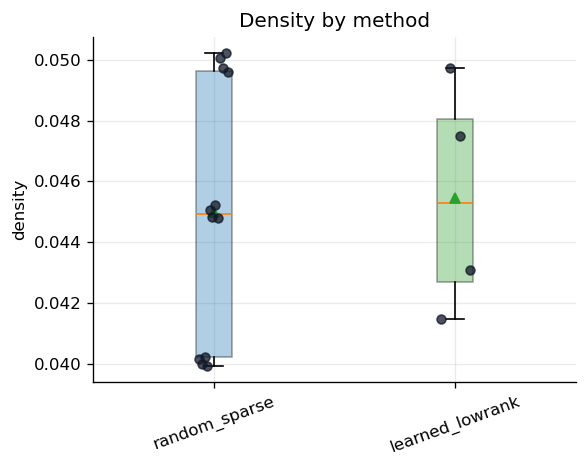

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/density_by_method.png


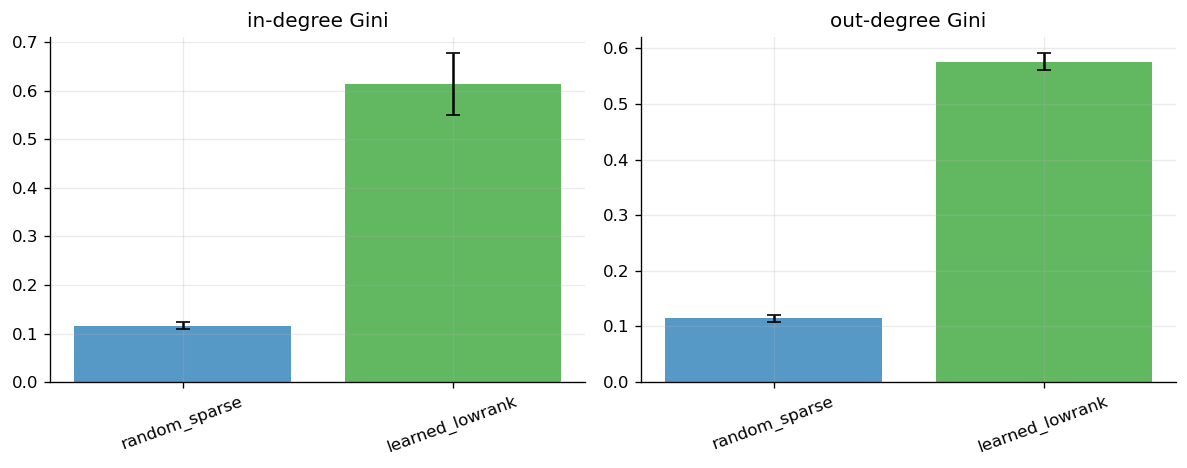

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/degree_heterogeneity_by_method.png


/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1118434948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)


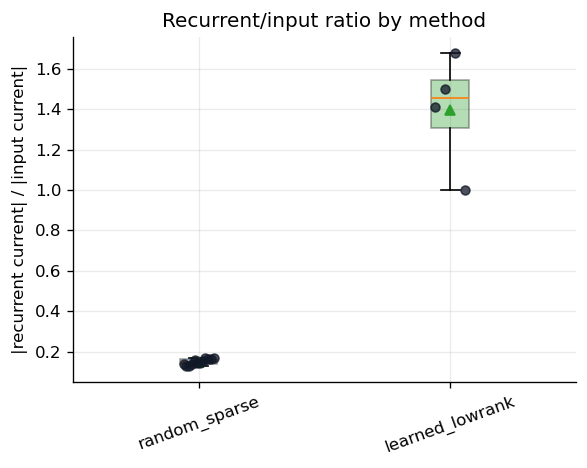

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/recurrent_input_ratio_by_method.png


/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1118434948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)


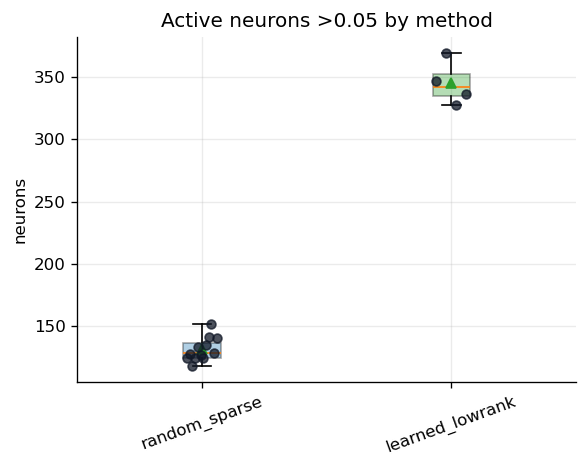

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/active_neurons_gt005_by_method.png


/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1118434948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)


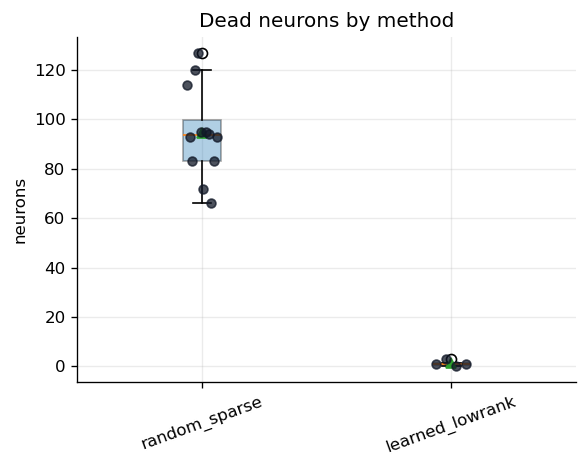

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/dead_neurons_by_method.png


/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1118434948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)


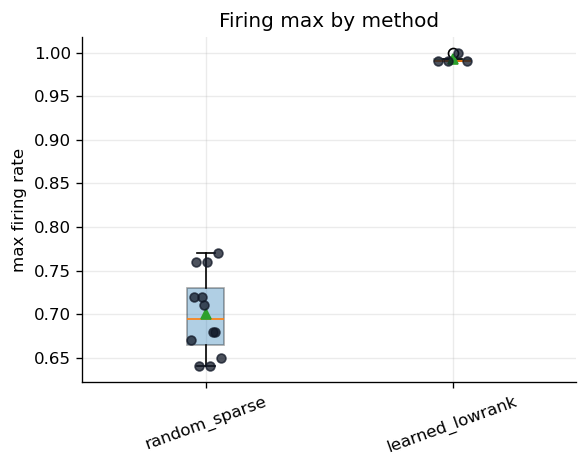

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/firing_max_by_method.png


In [9]:
saved_figures = []

def method_positions(methods):
    return np.arange(len(methods))

def savefig(fig, name: str):
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    saved_figures.append(path)
    print(f"Saved: {path}")

def plot_metric_by_method(metric: str, title: str, ylabel: str | None = None, filename: str | None = None):
    if metric not in df.columns or not df[metric].notna().any():
        print(f"Skipping {title}: missing {metric}")
        return
    methods = ordered_methods(df.loc[df[metric].notna(), "method"])
    data = [pd.to_numeric(df.loc[df["method"] == m, metric], errors="coerce").dropna().values for m in methods]
    fig, ax = plt.subplots(figsize=(max(5, 1.2 * len(methods)), 4))
    bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)
    for patch, method in zip(bp["boxes"], methods):
        patch.set_facecolor(METHOD_COLORS.get(method, METHOD_COLORS["unknown"]))
        patch.set_alpha(0.35)
    for i, vals in enumerate(data, start=1):
        jitter = np.linspace(-0.06, 0.06, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=28, color="#111827", alpha=0.75, zorder=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel or metric)
    ax.tick_params(axis="x", rotation=20)
    savefig(fig, filename or f"{metric}_by_method.png")

plot_metric_by_method("density", "Density by method", "density", "density_by_method.png")

if df.get("in_degree_gini", pd.Series(dtype=float)).notna().any() or df.get("out_degree_gini", pd.Series(dtype=float)).notna().any():
    hetero_metrics = [("in_degree_gini", "in-degree Gini"), ("out_degree_gini", "out-degree Gini")]
else:
    hetero_metrics = [("in_degree_std", "in-degree std"), ("out_degree_std", "out-degree std")]

available_hetero = [(m, label) for m, label in hetero_metrics if m in df.columns and df[m].notna().any()]
if available_hetero:
    fig, axes = plt.subplots(1, len(available_hetero), figsize=(5 * len(available_hetero), 4), squeeze=False)
    for ax, (metric, label) in zip(axes[0], available_hetero):
        methods = ordered_methods(df.loc[df[metric].notna(), "method"])
        means = [df.loc[df["method"] == m, metric].mean() for m in methods]
        stds = [df.loc[df["method"] == m, metric].std() for m in methods]
        ax.bar(methods, means, yerr=stds, color=[METHOD_COLORS.get(m, METHOD_COLORS["unknown"]) for m in methods], alpha=0.75, capsize=4)
        ax.set_title(label)
        ax.tick_params(axis="x", rotation=20)
    savefig(fig, "degree_heterogeneity_by_method.png")
else:
    print("Skipping degree heterogeneity plot: no Gini or degree std columns available")

plot_metric_by_method("recurrent_input_ratio", "Recurrent/input ratio by method", "|recurrent current| / |input current|", "recurrent_input_ratio_by_method.png")
plot_metric_by_method("active_neurons_gt_005", "Active neurons >0.05 by method", "neurons", "active_neurons_gt005_by_method.png")
plot_metric_by_method("dead_neurons", "Dead neurons by method", "neurons", "dead_neurons_by_method.png")
plot_metric_by_method("firing_max", "Firing max by method", "max firing rate", "firing_max_by_method.png")

Cosine alone may not explain accuracy; inspect it alongside dynamics and readout-specific separability.

/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1118434948.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showmeans=True)


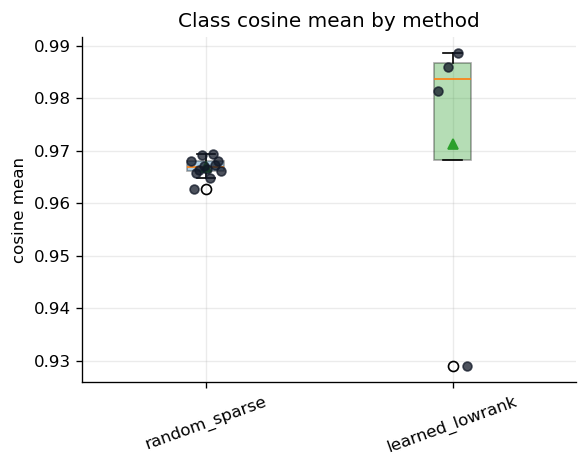

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/class_cosine_mean_by_method.png
Skipping Readout margin by method: missing readout_margin_mean


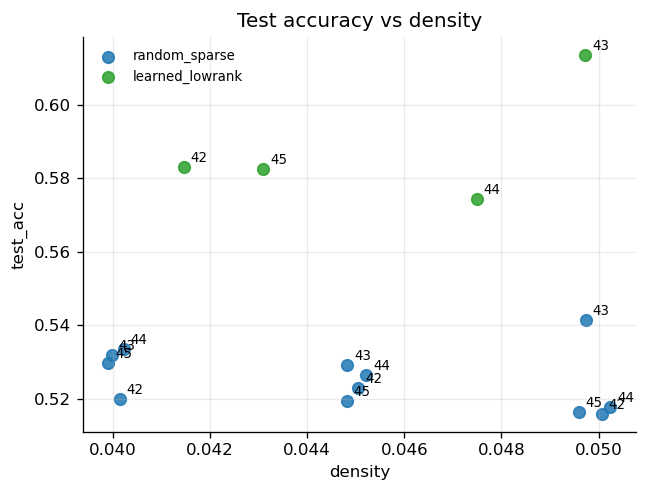

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/test_acc_vs_density.png


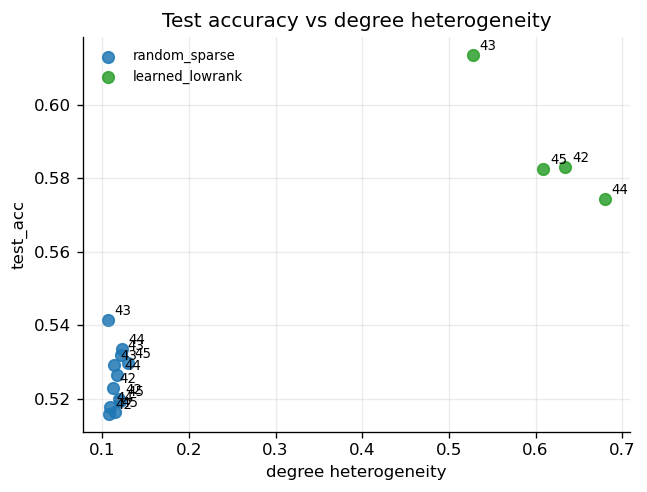

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/test_acc_vs_in_degree_gini.png


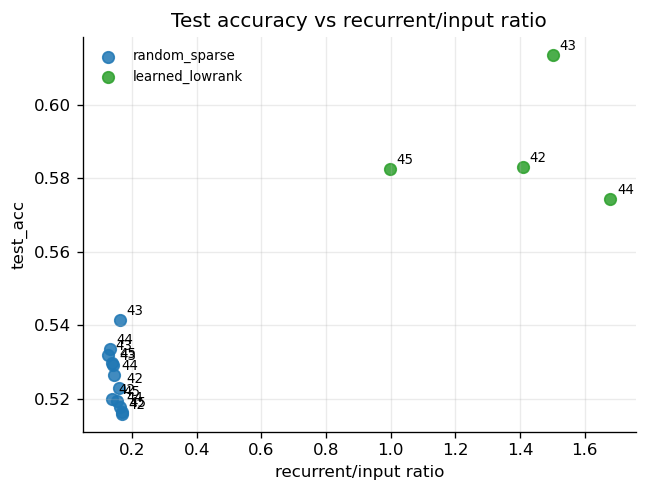

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/test_acc_vs_recurrent_input_ratio.png


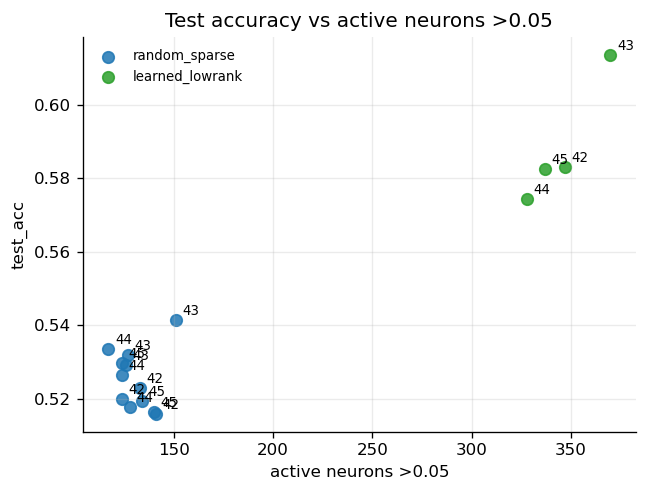

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/test_acc_vs_active_neurons_gt_005.png


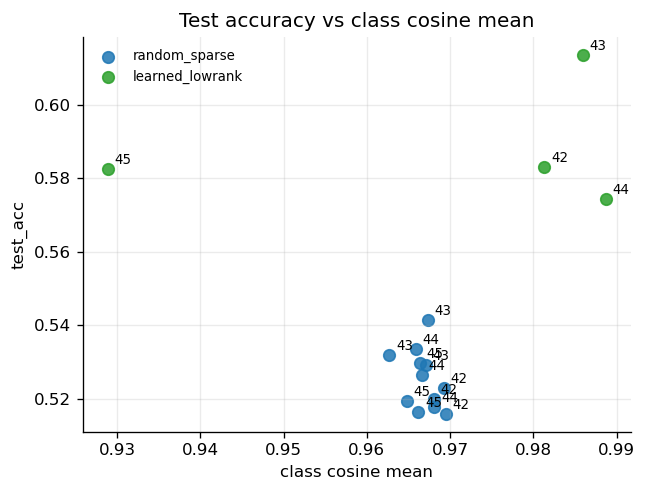

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/test_acc_vs_class_cosine_mean.png
Skipping test_acc vs readout_margin_mean: missing readout_margin_mean


In [10]:
plot_metric_by_method("class_cosine_mean", "Class cosine mean by method", "cosine mean", "class_cosine_mean_by_method.png")
plot_metric_by_method("readout_margin_mean", "Readout margin by method", "margin", "readout_margin_by_method.png")

def scatter_vs_test(metric: str, label: str | None = None):
    if "test_acc" not in df.columns or not df["test_acc"].notna().any():
        print(f"Skipping test_acc vs {metric}: missing test_acc")
        return
    if metric not in df.columns or not df[metric].notna().any():
        print(f"Skipping test_acc vs {metric}: missing {metric}")
        return
    sub = df[["method", "seed", "test_acc", metric]].copy()
    sub["test_acc"] = pd.to_numeric(sub["test_acc"], errors="coerce")
    sub[metric] = pd.to_numeric(sub[metric], errors="coerce")
    sub = sub.dropna(subset=["test_acc", metric])
    if sub.empty:
        print(f"Skipping test_acc vs {metric}: no complete rows")
        return
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    for method in ordered_methods(sub["method"]):
        ss = sub[sub["method"] == method]
        ax.scatter(ss[metric], ss["test_acc"], s=48, label=method, color=METHOD_COLORS.get(method, METHOD_COLORS["unknown"]), alpha=0.85)
        if len(ss) <= 20:
            for _, r in ss.iterrows():
                if pd.notna(r.get("seed")):
                    ax.annotate(str(int(r["seed"])), (r[metric], r["test_acc"]), xytext=(4, 3), textcoords="offset points", fontsize=8)
    ax.set_xlabel(label or metric)
    ax.set_ylabel("test_acc")
    ax.set_title(f"Test accuracy vs {label or metric}")
    ax.legend(frameon=False, fontsize=8)
    savefig(fig, f"test_acc_vs_{metric}.png")

scatter_metrics = [
    ("density", "density"),
    ("in_degree_gini" if df.get("in_degree_gini", pd.Series(dtype=float)).notna().any() else "in_degree_std", "degree heterogeneity"),
    ("recurrent_input_ratio", "recurrent/input ratio"),
    ("active_neurons_gt_005", "active neurons >0.05"),
    ("class_cosine_mean", "class cosine mean"),
    ("readout_margin_mean", "readout margin"),
]
for metric, label in scatter_metrics:
    scatter_vs_test(metric, label)

## Degree distribution plots if raw per-node degree files exist

In [11]:
def find_optional_files(patterns):
    roots = [OUT_DIR, ROOT / "experiments"]
    files = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            files.extend(root.glob(pattern))
    return sorted(set(files))

def run_name_from_path(path: Path) -> str:
    parts = path.parts
    if "experiments" in parts:
        idx = parts.index("experiments")
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return path.stem

def method_for_run(run_name: str) -> str:
    matches = df.loc[df["run_name"] == run_name, "method"]
    if len(matches):
        return str(matches.iloc[0])
    return METHOD_OVERRIDES.get(run_name, infer_method(run_name))

degree_files = find_optional_files(["degree_distribution.csv", "*_degree_distribution.csv", "*/degree_distribution.csv", "*/*_degree_distribution.csv"])
json_files = find_optional_files(["diagnose_topology.json", "*/diagnose_topology.json"])
degree_records = []

for path in degree_files:
    try:
        deg = pd.read_csv(path)
    except Exception as exc:
        print(f"Could not read {path}: {exc}")
        continue
    cols = {c.lower(): c for c in deg.columns}
    run = run_name_from_path(path)
    for kind, candidates in {"in_degree": ["in_degree", "in", "in_deg"], "out_degree": ["out_degree", "out", "out_deg"]}.items():
        col = next((cols[c] for c in candidates if c in cols), None)
        if col:
            for value in pd.to_numeric(deg[col], errors="coerce").dropna():
                degree_records.append({"run_name": run, "method": method_for_run(run), "kind": kind, "degree": value})

for path in json_files:
    try:
        data = json.loads(path.read_text())
    except Exception:
        continue
    run = run_name_from_path(path)
    for kind, keys in {"in_degree": ["in_degree", "in_degrees"], "out_degree": ["out_degree", "out_degrees"]}.items():
        found = None
        stack = [data]
        while stack and found is None:
            obj = stack.pop()
            if isinstance(obj, dict):
                for k, v in obj.items():
                    if k in keys and isinstance(v, list):
                        found = v
                        break
                    if isinstance(v, (dict, list)):
                        stack.append(v)
            elif isinstance(obj, list):
                stack.extend([v for v in obj if isinstance(v, (dict, list))])
        if found is not None:
            for value in pd.to_numeric(pd.Series(found), errors="coerce").dropna():
                degree_records.append({"run_name": run, "method": method_for_run(run), "kind": kind, "degree": value})

degree_df = pd.DataFrame(degree_records)
if degree_df.empty:
    print("No raw per-node in/out degree arrays found. Enhanced diagnose script must export per-node degrees for histograms.")
else:
    for kind in ["in_degree", "out_degree"]:
        sub = degree_df[degree_df["kind"] == kind]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(6, 4))
        for method in ordered_methods(sub["method"]):
            vals = sub.loc[sub["method"] == method, "degree"]
            ax.hist(vals, bins=30, alpha=0.35, density=True, label=method, color=METHOD_COLORS.get(method, METHOD_COLORS["unknown"]))
        ax.set_title(f"{kind.replace('_', ' ')} distribution")
        ax.set_xlabel("degree")
        ax.set_ylabel("density")
        ax.legend(frameon=False)
        savefig(fig, f"{kind}_histogram_by_method.png")

No raw per-node in/out degree arrays found. Enhanced diagnose script must export per-node degrees for histograms.


## Lowrank embedding PCA visualization

Found 16 class-vector embedding files. Projecting class mean-rate vectors to 2D PCA for visualization.


/var/folders/_2/xcfq65k14fsfgp0n7w86w3_m0000gn/T/ipykernel_69880/1332194652.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(class_ids), 1))


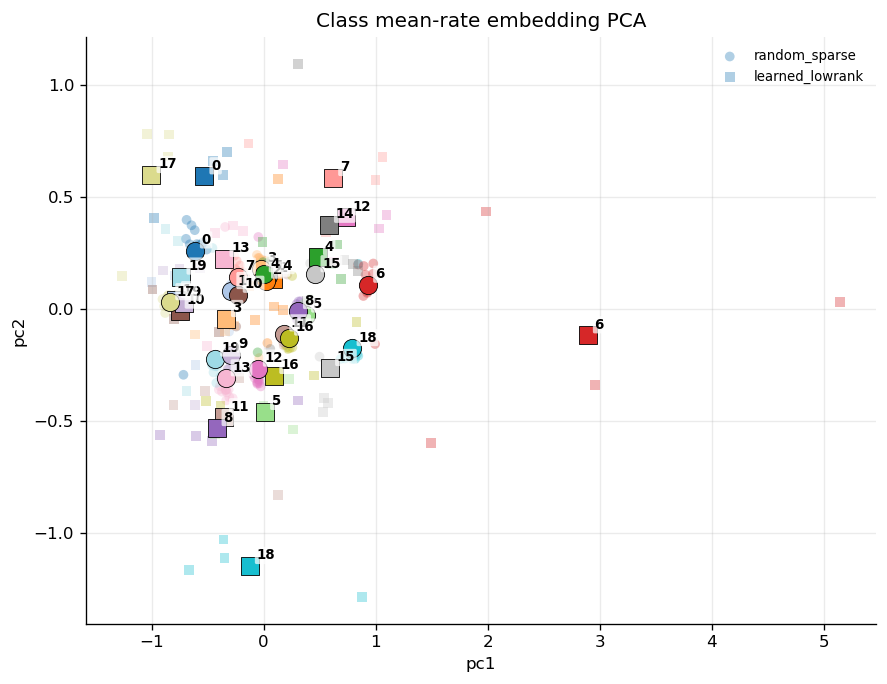

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/class_vector_embedding_pca.png


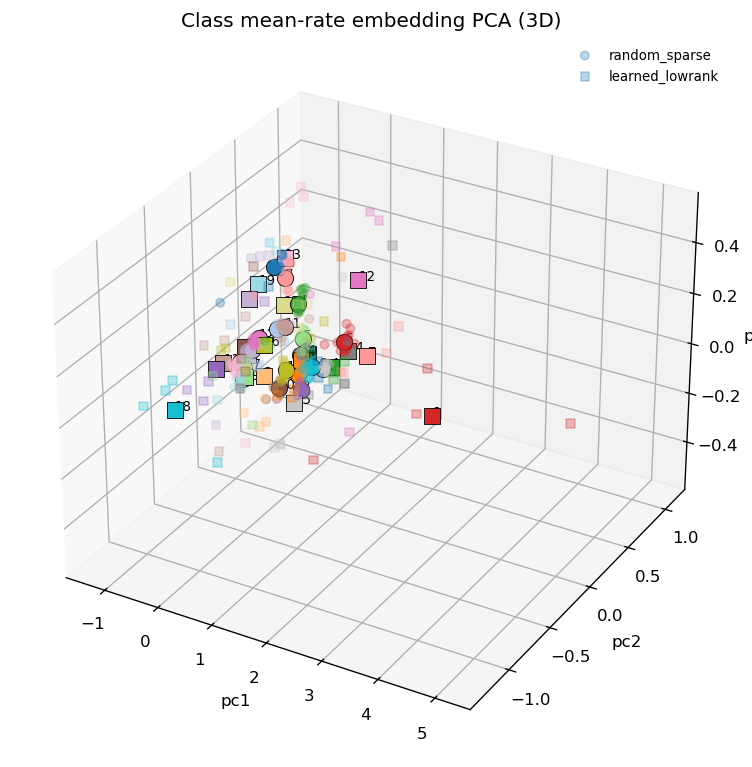

Saved: /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/class_vector_embedding_pca_3d.png


In [12]:
embedding_files = find_optional_files(["embedding_pca.csv", "*_embedding_pca.csv", "*/embedding_pca.csv", "*/*_embedding_pca.csv"])
topology_pca_records = []
class_vector_records = []

for path in embedding_files:
    try:
        emb = pd.read_csv(path)
    except Exception as exc:
        print(f"Could not read {path}: {exc}")
        continue
    cols = {c.lower(): c for c in emb.columns}
    run = run_name_from_path(path)
    method = method_for_run(run)

    has_src = "src_pc1" in cols and "src_pc2" in cols
    has_dst = "dst_pc1" in cols and "dst_pc2" in cols
    if has_src or has_dst:
        emb = emb.copy()
        emb["run_name"] = run
        emb["method"] = method
        topology_pca_records.append(emb)
        continue

    feature_cols = [c for c in emb.columns if re.fullmatch(r"n\d+", str(c))]
    if "class" in emb.columns and len(feature_cols) >= 2:
        x = emb[feature_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        x_centered = x - x.mean(axis=0, keepdims=True)
        _, _, vt = np.linalg.svd(x_centered, full_matrices=False)
        with np.errstate(all="ignore"):
            coords = x_centered @ vt[:3].T
        if coords.shape[1] == 1:
            coords = np.concatenate([coords, np.zeros((coords.shape[0], 2))], axis=1)
        elif coords.shape[1] == 2:
            coords = np.concatenate([coords, np.zeros((coords.shape[0], 1))], axis=1)
        proj = pd.DataFrame({
            "pc1": coords[:, 0],
            "pc2": coords[:, 1],
            "pc3": coords[:, 2],
            "class": emb["class"].astype(str),
            "run_name": run,
            "method": method,
        })
        class_vector_records.append(proj)

if topology_pca_records:
    pca_df = pd.concat(topology_pca_records, ignore_index=True)
    cols = {c.lower(): c for c in pca_df.columns}
    type_col = next((cols[c] for c in ["neuron_type", "ei_type", "type", "dale_type"] if c in cols), None)
    degree_col = next((cols[c] for c in ["degree", "total_degree", "in_degree", "out_degree"] if c in cols), None)
    for prefix, title in [("src", "Source embedding PCA"), ("dst", "Destination embedding PCA")]:
        x_col = cols.get(f"{prefix}_pc1")
        y_col = cols.get(f"{prefix}_pc2")
        if not x_col or not y_col:
            print(f"Skipping {title}: missing {prefix}_pc1/{prefix}_pc2")
            continue
        fig, ax = plt.subplots(figsize=(5.5, 5))
        if type_col:
            for neuron_type, ss in pca_df.groupby(type_col):
                sizes = 20 + 2 * pd.to_numeric(ss[degree_col], errors="coerce").fillna(1) if degree_col else 28
                ax.scatter(ss[x_col], ss[y_col], s=sizes, alpha=0.65, label=str(neuron_type))
            ax.legend(frameon=False, fontsize=8)
        else:
            sizes = 20 + 2 * pd.to_numeric(pca_df[degree_col], errors="coerce").fillna(1) if degree_col else 28
            ax.scatter(pca_df[x_col], pca_df[y_col], s=sizes, alpha=0.65, color="#2ca02c")
        ax.set_title(title)
        ax.set_xlabel(f"{prefix}_pc1")
        ax.set_ylabel(f"{prefix}_pc2")
        savefig(fig, f"{prefix}_embedding_pca.png")
elif class_vector_records:
    class_pca_df = pd.concat(class_vector_records, ignore_index=True)
    print(f"Found {len(class_vector_records)} class-vector embedding files. Projecting class mean-rate vectors to 2D PCA for visualization.")
    class_ids = sorted(class_pca_df["class"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))
    cmap = plt.cm.get_cmap("tab20", max(len(class_ids), 1))
    class_to_color = {cls: cmap(i) for i, cls in enumerate(class_ids)}
    method_to_marker = {
        "random_sparse": "o",
        "learned_lowrank": "s",
        "grad_r": "^",
        "no_recurrence": "x",
        "unknown": "d",
    }
    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    for method in ordered_methods(class_pca_df["method"]):
        ss = class_pca_df[class_pca_df["method"] == method]
        colors = [class_to_color[c] for c in ss["class"]]
        ax.scatter(
            ss["pc1"],
            ss["pc2"],
            s=34,
            alpha=0.35,
            c=colors,
            marker=method_to_marker.get(method, "o"),
            label=method,
            edgecolors="none",
        )
    centroids = class_pca_df.groupby(["method", "class"], as_index=False)[["pc1", "pc2"]].mean()
    for _, row in centroids.iterrows():
        color = class_to_color[row["class"]]
        marker = method_to_marker.get(row["method"], "o")
        ax.scatter(
            [row["pc1"]],
            [row["pc2"]],
            s=120,
            c=[color],
            marker=marker,
            edgecolors="black",
            linewidths=0.5,
            zorder=4,
        )
        ax.annotate(
            str(row["class"]),
            (row["pc1"], row["pc2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            weight="bold",
            color="black",
            bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.7),
            zorder=5,
        )
    ax.set_title("Class mean-rate embedding PCA")
    ax.set_xlabel("pc1")
    ax.set_ylabel("pc2")
    ax.legend(frameon=False, fontsize=8)
    savefig(fig, "class_vector_embedding_pca.png")

    fig = plt.figure(figsize=(8, 6.5))
    ax = fig.add_subplot(111, projection="3d")
    for method in ordered_methods(class_pca_df["method"]):
        ss = class_pca_df[class_pca_df["method"] == method]
        colors = [class_to_color[c] for c in ss["class"]]
        ax.scatter(
            ss["pc1"],
            ss["pc2"],
            ss["pc3"],
            s=26,
            alpha=0.30,
            c=colors,
            marker=method_to_marker.get(method, "o"),
            label=method,
            depthshade=False,
        )
    for _, row in centroids.iterrows():
        color = class_to_color[row["class"]]
        marker = method_to_marker.get(row["method"], "o")
        z = class_pca_df.loc[
            (class_pca_df["method"] == row["method"]) & (class_pca_df["class"] == row["class"]),
            "pc3",
        ].mean()
        ax.scatter(
            [row["pc1"]],
            [row["pc2"]],
            [z],
            s=95,
            c=[color],
            marker=marker,
            edgecolors="black",
            linewidths=0.5,
            depthshade=False,
        )
        ax.text(row["pc1"], row["pc2"], z, str(row["class"]), fontsize=8)
    ax.set_title("Class mean-rate embedding PCA (3D)")
    ax.set_xlabel("pc1")
    ax.set_ylabel("pc2")
    ax.set_zlabel("pc3")
    ax.legend(frameon=False, fontsize=8)
    savefig(fig, "class_vector_embedding_pca_3d.png")
else:
    print("No embedding_pca.csv files found under runs/diagnostics or experiments/. Run diagnose_liquid.py with --save-embeddings.")

## Interpretation helpers

- If density is similar but degree Gini differs, that supports topology-fingerprint difference.
- If graph metrics differ but `recurrent_input_ratio`/firing do not, structure may not be functionally active.
- If graph+dynamics differ but readout margin does not, performance mechanism is not established.
- If class cosine does not align with test accuracy, avoid claiming global mean-rate separation.
- If readout margin aligns with test accuracy, emphasize readout-specific separability.

## Outputs

In [13]:
print("Generated outputs:")
for path in [GROUP_SUMMARY_PATH, SEED_SUMMARY_PATH, PAPER_TABLE_PATH, FIG_DIR]:
    print(f"- {path}")
if saved_figures:
    print("\nFigures:")
    for path in saved_figures:
        print(f"- {path}")

Generated outputs:
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_group_summary.csv
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_seed_summary.csv
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/topology_paper_table.csv
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures

Figures:
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/density_by_method.png
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/degree_heterogeneity_by_method.png
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/recurrent_input_ratio_by_method.png
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/active_neurons_gt005_by_method.png
- /Users/jeong-yunseong/Documents/programming/snn_gumbel/runs/diagnostics/figures/dead_neurons_by_method.png
- /Users/jeong-yunseong/